In [27]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH
import gplugins.tidy3d.materials as mat

nm = 1e-3

In [51]:
import upvfab_design_tools
import importlib

importlib.reload(upvfab_design_tools)
from upvfab_design_tools import MMI_EME, DC_EME

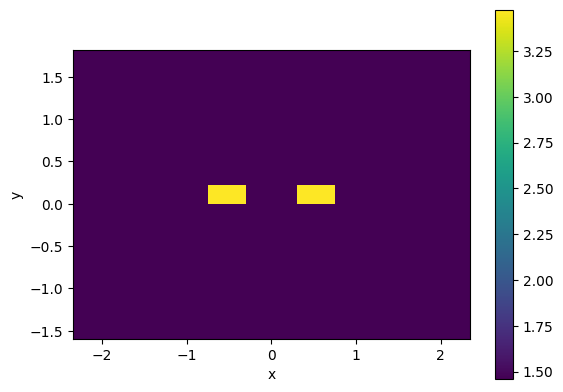

In [3]:
dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(450 * nm, 450 * nm), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=220 * nm, # Waveguide height, proceso de nitruro 
    gap=600 * nm,
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.6, # Parameters of the grid
    grid_resolution=40 # Parameters of the grid
)

dcoupler_cs.plot_index()

A practical design strategy consists in first selecting the waveguide gap according to the fabrication constraints imposed by the target foundry process.

Once a fabrication-compatible separation is identified, the coupling ratio can be engineered by tuning the interaction length of the directional coupler.

Personal notes:

- Check PIC-UPV-LAB2 practice.


In [4]:
step_size = 0.1
gap_variation = np.arange(0.5, 1.5+step_size, step_size)

neff_even = []
neff_odd = []

for g in gap_variation:
    coupler = gt.modes.WaveguideCoupler(
        core_width=(450 * nm, 450 * nm), # Waveguide width
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        core_thickness=220 * nm, # Waveguide height
        gap=g,
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        wavelength=1550 * nm, # Wavelength to simulate
        num_modes=4,
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.6, # Parameters of the grid
        grid_resolution=40 # Parameters of the grid
    )
    
    neff_even.append(coupler.n_eff[0])
    neff_odd.append(coupler.n_eff[1])

neff_even = np.array(neff_even)
neff_odd = np.array(neff_odd)

Lpi = (1550 * nm) / (2 * (neff_even.real - neff_odd.real))

2026-05-10 14:22:44.211 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_be0d783acf7b79d3.npz.
2026-05-10 14:22:44.246 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_73655da80e0e289e.npz.
2026-05-10 14:22:44.248 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_385f990b1ca4e09b.npz.
2026-05-10 14:22:44.250 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d5f2205da32ba4f8.npz.
2026-05-10 14:22:44.252 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_908022a42206e9e6.npz.
2026-05-10 14:22:44.255 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_9d55a89b3f3480d8.npz.
2026-05-10 14:22:44.257 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_9846a1e306354450.npz.
2026-05-10 14:22:44.260 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

In [8]:
np.save("Gap_vs_Lpi.npy", {
    "gap": gap_variation,
    "Lpi": Lpi
})

In [9]:
data = np.load("Gap_vs_Lpi.npy", allow_pickle=True).item()

gap = data["gap"]
Lpi = data["Lpi"]

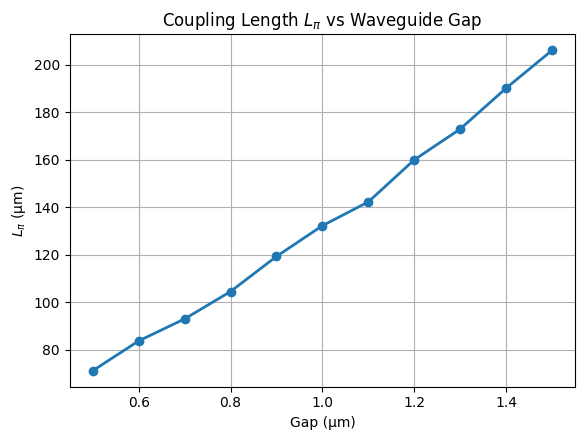

In [10]:
plt.figure(figsize=(7, 4.5))
plt.plot(gap, Lpi,'o-', linewidth=2, markersize=6)
plt.xlabel("Gap (µm)")
plt.ylabel(r"$L_{\pi}$ (µm)")
plt.title(r"Coupling Length $L_{\pi}$ vs Waveguide Gap")
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1])
# plt.savefig('LO3_Deep_TE_0.png', bbox_inches='tight')

In [7]:
Lpi

array([ 71.0924846 ,  83.63165956,  92.91089996, 104.43855299,
       119.21210277, 132.16215624, 142.18578819, 159.89400115,
       172.87625841, 190.08377776, 206.00579724])


\begin{equation}
\begin{bmatrix}
E_{\mathrm{out0}} \\
E_{\mathrm{out1}}
\end{bmatrix}
=
\begin{bmatrix}
\tau & j\kappa \\
j\kappa & \tau
\end{bmatrix}
\begin{bmatrix}
E_{\mathrm{in0}} \\
E_{\mathrm{in1}}
\end{bmatrix}
% \tag{1.5}
\end{equation}

\begin{equation}
\kappa = \sin^2 \left(
\frac{1}{2}\pi
\left(
\frac{L}{L_{\pi \mathrm{TE/TM}}}
\right)
\right)
% \tag{1.6}
\end{equation}

In [11]:
def coupling_coefficient(ratio):
    return np.sin((ratio*np.pi)/2)**2

Esta es una solución bastante aproximada, no se estan considerando en absoluto las perdidas asociadas al DC, se espera mejorar esto a futuro.

In [13]:
Lpi = 83.6316  #um

couplings = np.array([0.5, 0.17, 0.23, 0.05, 0.3])

L_values = (2 * Lpi / np.pi) * np.arcsin(np.sqrt(couplings))

for c, L in zip(couplings, L_values):
    print(f"Coupling = {c:.2f} --> L = {L:.2f} um")

Coupling = 0.50 --> L = 41.82 um
Coupling = 0.17 --> L = 22.63 um
Coupling = 0.23 --> L = 26.63 um
Coupling = 0.05 --> L = 12.01 um
Coupling = 0.30 --> L = 30.86 um


---

## Ideas no usadas

Podriamos tomar este codigo como referencia para jugar con las longitudes de Lpi que encontramos en el apartado anterior y ver como se comporta el DC

In [58]:
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 450 * nm # Student. Core waveguides width
d = wg_width + wg_gap
wg_N = 2


m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.mat_core=mat.si(1.55)
m.MMI_num_modes = 40 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N
m.VERBOSE = True

In [59]:
m.find_all_modes()

[Mode(k: (6.057603126467766+0j), n_eff:(1.4943510953427106+0j)), Mode(k: (6.024716465779461+0j), n_eff:(1.4862382796966995+0j))]
Wavelength 1.55  µm
---------------------------------------------
Core refractive index: 3.4750055639285913
--- Mode #0  --------------------------------
Effective refractive index: 1.4944+0.0000j
TE fraction: 0.9938
TM fraction: 0.0062
Confinement factor: 0.2144+0.0000j
--- Mode #1  --------------------------------
Effective refractive index: 1.4862+0.0000j
TE fraction: 0.0045
TM fraction: 0.9955
Confinement factor: 0.1295+0.0000j
---------------------------------------------
Cladding refractive index: 1.4577374304687887
TE number: 1, TM number: 1, n_all: 2


/home/nixtropy/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


IndexError: list index out of range

In [62]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 10  # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.mat_core=mat.si(1.55)
m.MMI_width = mmi_Width
m.wg_width = 450 * nm
m.MMI_num_modes = 40 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.VERBOSE = True
m.find_all_modes()

# 2) Get the L_pi 
L_pi_eme = m.get_L_pi()

[Mode(k: (6.804392652879697+0j), n_eff:(1.6785767244381677+0j)), Mode(k: (6.783953833534725+0j), n_eff:(1.6735346687871102+0j)), Mode(k: (6.749795806822247+0j), n_eff:(1.6651082196508986+0j)), Mode(k: (6.701781580981417+0j), n_eff:(1.6532635825098856+0j)), Mode(k: (6.639725913914893+0j), n_eff:(1.6379550599611072+0j)), Mode(k: (6.56340734113498+0j), n_eff:(1.6191280188942623+0j)), Mode(k: (6.472595192731129+0j), n_eff:(1.5967255553117976+0j)), Mode(k: (6.388024501199801+0j), n_eff:(1.575862797735036+0j)), Mode(k: (6.367111969544629+0j), n_eff:(1.570703881917532+0j)), Mode(k: (6.367802789480874+0j), n_eff:(1.5708743003993737+0j)), Mode(k: (6.334040332129701+0j), n_eff:(1.5625454343329026+0j)), Mode(k: (6.286662824360587+0j), n_eff:(1.5508578692760173+0j)), Mode(k: (6.246991196617449+0j), n_eff:(1.5410712690094932+0j)), Mode(k: (6.225605152694255+0j), n_eff:(1.5357955423739804+0j)), Mode(k: (6.150886453132142+0j), n_eff:(1.5173631742900822+0j)), Mode(k: (6.112981062214322+0j), n_eff:(1.5

/home/nixtropy/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


n_MODES= 11
Lπ 2D = 153.71 µm
[Mode(k: (6.804392652879697+0j), n_eff:(1.6785767244381677+0j)), Mode(k: (6.783953833534725+0j), n_eff:(1.6735346687871102+0j)), Mode(k: (6.749795806822247+0j), n_eff:(1.6651082196508986+0j)), Mode(k: (6.701781580981417+0j), n_eff:(1.6532635825098856+0j)), Mode(k: (6.639725913914893+0j), n_eff:(1.6379550599611072+0j)), Mode(k: (6.56340734113498+0j), n_eff:(1.6191280188942623+0j)), Mode(k: (6.472595192731129+0j), n_eff:(1.5967255553117976+0j)), Mode(k: (6.388024501199801+0j), n_eff:(1.575862797735036+0j)), Mode(k: (6.367111969544629+0j), n_eff:(1.570703881917532+0j)), Mode(k: (6.367802789480874+0j), n_eff:(1.5708743003993737+0j)), Mode(k: (6.334040332129701+0j), n_eff:(1.5625454343329026+0j)), Mode(k: (6.286662824360587+0j), n_eff:(1.5508578692760173+0j)), Mode(k: (6.246991196617449+0j), n_eff:(1.5410712690094932+0j)), Mode(k: (6.225605152694255+0j), n_eff:(1.5357955423739804+0j)), Mode(k: (6.150886453132142+0j), n_eff:(1.5173631742900822+0j)), Mode(k: (6.1

/home/nixtropy/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/1673 [00:00<?, ?it/s]

------- Pameters -------
MMI length 83.6316
MMI length increment 0.0000
IO wg width 0.4500
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.6296
Total OUT power: 0.1192
Excess loss [dB] =  9.2377
------------------------
Power over OUTs:  ['0.1076', '0.0116']
Ratio over OUTs ['0.9024', '0.0976']


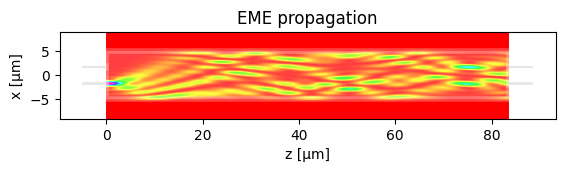

In [64]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)

m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT
m.dL_MMI = 0
dy = 0
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([-1.68, 1.68]) # STUDENT
m.OUT_WVG_positions =np.array([-1.68, 1.68])# STUDENT

# MMI length (check class slides for type of MMI)
# m.L_MMI = L_pi_eme
m.L_MMI = 83.6316
m.VERBOSE = True

# Run propagation
m.propagation()